Filtered sample size: 348
Cook's threshold: 0.010753
Loaded coefficient file with 1000 iterations and 48 features.
Prediction matrix shape: (1000, 348)
Saved:
- observation summary predictions
- observation-level predictions for all iterations
- yearly summary with uncertainty bands


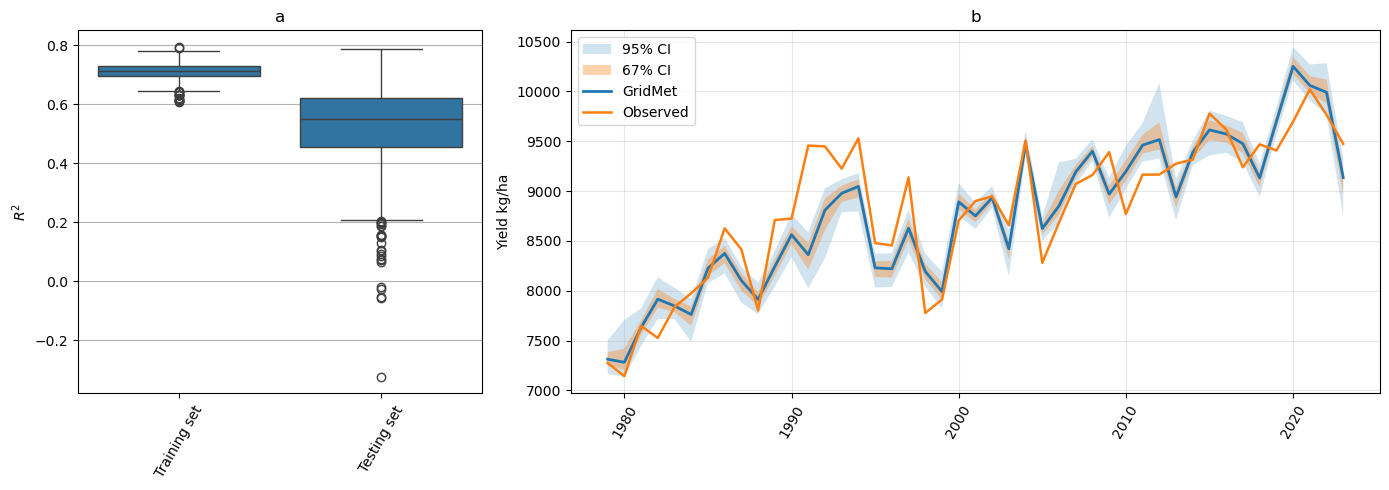

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# =========================================================
# File paths
# =========================================================

CLIMATE_DIR = "/group/moniergrp/dbaral"
file_path = os.path.join(CLIMATE_DIR, "run_project/input_data/gridmet_hist_model_input")
save_path = os.path.join(CLIMATE_DIR, "run_project/output_data/historical_model")

# input files from your 1000-model HPC run
coef_file = os.path.join(save_path, "gridmet_lasso_1000_iterations_coefficients_no_intercept.csv")
metrics_file = os.path.join(save_path, "gridmet_lasso_1000_iterations_stability_metrics_no_intercept.csv")

# optional metadata file from final model
metadata_file = os.path.join(save_path, "gridmet_hist_model_metadata_no_intercept.json")

os.makedirs(save_path, exist_ok=True)


# =========================================================
# Helper 1
# Load raw historical data
# =========================================================

def load_raw_data():
    df = pd.read_csv(os.path.join(file_path, "Lasso_Model_Input_Variables_1979_2023_v2.csv"))
    return df


# =========================================================
# Helper 2
# Build design matrix exactly like training
# =========================================================

def build_design_matrix(df):
    """
    Rebuild the historical design matrix exactly like the model training code.

    Important:
        - remove rows with missing yield
        - center only climate variables
        - create squared terms from centered climate variables
        - include all county dummies
        - create county-specific trends starting at 0
        - no intercept column
    """

    df_model = df.copy()

    # -----------------------------------------------------
    # Step 1: remove rows with missing yield
    # -----------------------------------------------------
    df_model = df_model[df_model["yield_kg_ha"].notna()].copy()

    # -----------------------------------------------------
    # Step 2: define climate predictors
    # -----------------------------------------------------
    cols_exclude = ["county", "year", "yield_kg_ha"]
    climate_cols = [c for c in df_model.columns if c not in cols_exclude]

    # -----------------------------------------------------
    # Step 3: center only climate variables
    # -----------------------------------------------------
    climate_center_means = {}
    for col in climate_cols:
        mean_val = df_model[col].mean()
        climate_center_means[col] = float(mean_val)
        df_model[col] = df_model[col] - mean_val

    # -----------------------------------------------------
    # Step 4: create squared terms
    # -----------------------------------------------------
    for col in climate_cols:
        df_model[f"{col}_sq"] = df_model[col] ** 2

    squared_cols = [f"{c}_sq" for c in climate_cols]

    # -----------------------------------------------------
    # Step 5: create all county dummies
    # -----------------------------------------------------
    county_dummies = pd.get_dummies(
        df_model["county"],
        prefix="county",
        drop_first=False
    ).astype(int)

    # -----------------------------------------------------
    # Step 6: create county-specific time trends
    # trend starts at 0
    # -----------------------------------------------------
    base_year = int(df_model["year"].min())
    time_trend = df_model["year"] - base_year

    county_trends = county_dummies.multiply(time_trend, axis=0)
    county_trends.columns = [c.replace("county", "trend") for c in county_trends.columns]

    # -----------------------------------------------------
    # Step 7: combine into final X
    # -----------------------------------------------------
    X_df = pd.concat(
        [
            df_model[climate_cols + squared_cols],
            county_dummies,
            county_trends
        ],
        axis=1
    )

    Y = df_model["yield_kg_ha"].copy()
    feature_cols_final = list(X_df.columns)

    return (
        df_model,
        X_df,
        Y,
        feature_cols_final,
        climate_cols,
        squared_cols,
        climate_center_means,
        base_year
    )


# =========================================================
# Helper 3
# Apply same Cook's-distance filtering used in training
# =========================================================

def remove_outliers_with_cooks_distance(df_model, X_df, Y):
    """
    Use the same Cook's-distance rule as training so that
    observed and predicted are compared on the same filtered sample.
    """

    X_const = sm.add_constant(X_df)
    model_sm = sm.OLS(Y, X_const).fit()

    influence = model_sm.get_influence()
    cooks_d = influence.cooks_distance[0]

    threshold = 4 / len(Y)
    mask = cooks_d < threshold

    df_filtered = df_model.loc[mask].copy()
    X_filtered = X_df.loc[mask].copy()
    Y_filtered = Y.loc[mask].copy()

    return df_filtered, X_filtered, Y_filtered, cooks_d, threshold, mask


# =========================================================
# Helper 4
# Load coefficient file and reshape to wide matrix
# =========================================================

def load_coefficient_matrix(coef_file, feature_cols_final):
    """
    Convert long coefficient table:
        iteration | feature | coefficient | alpha_selected
    into wide matrix:
        rows = iterations
        cols = feature columns
    """

    coef_long = pd.read_csv(coef_file)

    # pivot to wide
    coef_wide = coef_long.pivot(index="iteration", columns="feature", values="coefficient")

    # reindex columns to exact design-matrix order
    coef_wide = coef_wide.reindex(columns=feature_cols_final)

    # check for missing columns
    missing_cols = coef_wide.columns[coef_wide.isna().all()].tolist()
    if len(missing_cols) > 0:
        raise ValueError(f"These feature columns are missing in coefficient file: {missing_cols}")

    return coef_long, coef_wide


# =========================================================
# Helper 5
# Predict yield for all 1000 models
# =========================================================

def predict_all_models(X_filtered, coef_wide):
    """
    Predict for every observation using every model.

    Returns:
        pred_matrix: shape = (n_iterations, n_observations)
    """

    X_mat = X_filtered.values                       # n_obs x n_features
    B_mat = coef_wide.values                       # n_iter x n_features

    # prediction for all models at once
    pred_matrix = B_mat @ X_mat.T                  # n_iter x n_obs

    return pred_matrix


# =========================================================
# Helper 6
# Build observation-level prediction dataframe
# =========================================================

def build_observation_prediction_df(df_filtered, pred_matrix, coef_wide):
    """
    Create one dataframe with observed yield plus summary stats
    across the 1000 model predictions for each observation.
    """

    pred_df = df_filtered[["county", "year", "yield_kg_ha"]].copy().reset_index(drop=True)

    pred_df["pred_median"] = np.median(pred_matrix, axis=0)
    pred_df["pred_mean"] = np.mean(pred_matrix, axis=0)

    pred_df["pred_p2_5"] = np.percentile(pred_matrix, 2.5, axis=0)
    pred_df["pred_p16_5"] = np.percentile(pred_matrix, 16.5, axis=0)
    pred_df["pred_p83_5"] = np.percentile(pred_matrix, 83.5, axis=0)
    pred_df["pred_p97_5"] = np.percentile(pred_matrix, 97.5, axis=0)

    # optional: add each model's prediction as separate columns
    pred_matrix_df = pd.DataFrame(
        pred_matrix.T,
        columns=[f"pred_iter_{i}" for i in coef_wide.index]
    )

    pred_df_all = pd.concat([pred_df, pred_matrix_df], axis=1)

    return pred_df, pred_df_all


# =========================================================
# Helper 7
# Build yearly uncertainty summary across all 1000 models
# =========================================================

def build_yearly_prediction_summary(df_filtered, pred_matrix, coef_wide):
    """
    For each model iteration, compute yearly average predicted yield.
    Then summarize across iterations by year.
    """

    years = sorted(df_filtered["year"].unique())
    year_index = pd.Index(years, name="year")

    yearly_pred_list = []

    # loop over iterations
    for row_num, iteration in enumerate(coef_wide.index):
        temp_df = df_filtered[["year"]].copy()
        temp_df["predicted_yield"] = pred_matrix[row_num, :]

        yearly_avg = temp_df.groupby("year")["predicted_yield"].mean().reindex(year_index)

        yearly_pred_list.append(yearly_avg.values)

    yearly_pred_matrix = np.vstack(yearly_pred_list)   # n_iter x n_years

    # observed yearly average
    observed_yearly = (
        df_filtered.groupby("year")["yield_kg_ha"]
        .mean()
        .reindex(year_index)
    )

    summary_df = pd.DataFrame({
        "year": years,
        "observed_yield": observed_yearly.values,
        "pred_median": np.median(yearly_pred_matrix, axis=0),
        "pred_mean": np.mean(yearly_pred_matrix, axis=0),
        "pred_p2_5": np.percentile(yearly_pred_matrix, 2.5, axis=0),
        "pred_p16_5": np.percentile(yearly_pred_matrix, 16.5, axis=0),
        "pred_p83_5": np.percentile(yearly_pred_matrix, 83.5, axis=0),
        "pred_p97_5": np.percentile(yearly_pred_matrix, 97.5, axis=0),
    })

    return summary_df, yearly_pred_matrix


# =========================================================
# Plot 1
# Train vs test R2 boxplot from metrics file
# =========================================================

def plot_r2_boxplot(metrics_df, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 6))

    r2_long = metrics_df.melt(
        id_vars="iteration",
        value_vars=["R2_train", "R2_test"],
        var_name="set_type",
        value_name="R2"
    )

    r2_long["set_type"] = r2_long["set_type"].replace({
        "R2_train": "Training set",
        "R2_test": "Testing set"
    })

    sns.boxplot(data=r2_long, x="set_type", y="R2", ax=ax)
    ax.set_title("a")
    ax.set_xlabel("")
    ax.set_ylabel(r"$R^2$")
    ax.tick_params(axis="x", rotation=60)
    ax.grid(True, axis="y")


# =========================================================
# Plot 2
# Historical observed vs predicted yearly yield
# =========================================================

def plot_historical_prediction(summary_df, ax=None, pred_label="GridMet"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    x = summary_df["year"].values

    # 95% interval
    ax.fill_between(
        x,
        summary_df["pred_p2_5"].values,
        summary_df["pred_p97_5"].values,
        alpha=0.20,
        label="95% CI"
    )

    # 67% interval
    ax.fill_between(
        x,
        summary_df["pred_p16_5"].values,
        summary_df["pred_p83_5"].values,
        alpha=0.35,
        label="67% CI"
    )

    # median predicted
    ax.plot(
        x,
        summary_df["pred_median"].values,
        linewidth=2.0,
        label=pred_label
    )

    # observed
    ax.plot(
        x,
        summary_df["observed_yield"].values,
        linewidth=1.8,
        label="Observed"
    )

    ax.set_title("b")
    ax.set_xlabel("")
    ax.set_ylabel("Yield kg/ha")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=60)
    ax.legend(frameon=True)


# =========================================================
# Plot 3
# Climate coefficients from final model only
# =========================================================

def plot_climate_coefficients_from_final_model(coef_long, climate_cols, squared_cols):
    """
    Optional extra plot to inspect climate coefficients
    from the final full-sample model file if you want.
    """
    pass


# =========================================================
# Main workflow
# =========================================================

# -----------------------------------------------------
# Step 1: load raw historical data
# -----------------------------------------------------
df = load_raw_data()

# -----------------------------------------------------
# Step 2: rebuild design matrix exactly like training
# -----------------------------------------------------
(
    df_model,
    X_df,
    Y,
    feature_cols_final,
    climate_cols,
    squared_cols,
    climate_center_means,
    base_year
) = build_design_matrix(df)

# -----------------------------------------------------
# Step 3: apply same Cook's-distance filtering
# -----------------------------------------------------
df_filtered, X_filtered, Y_filtered, cooks_d, cooks_threshold, cooks_mask = remove_outliers_with_cooks_distance(
    df_model,
    X_df,
    Y
)

print(f"Filtered sample size: {len(df_filtered)}")
print(f"Cook's threshold: {cooks_threshold:.6f}")

# -----------------------------------------------------
# Step 4: load 1000-model coefficient file
# -----------------------------------------------------
coef_long, coef_wide = load_coefficient_matrix(coef_file, feature_cols_final)

print(f"Loaded coefficient file with {coef_wide.shape[0]} iterations and {coef_wide.shape[1]} features.")

# -----------------------------------------------------
# Step 5: predict for all 1000 models
# -----------------------------------------------------
pred_matrix = predict_all_models(X_filtered, coef_wide)

print("Prediction matrix shape:", pred_matrix.shape)   # (n_iterations, n_observations)

# -----------------------------------------------------
# Step 6: build prediction dataframes
# -----------------------------------------------------
pred_obs_summary_df, pred_obs_all_df = build_observation_prediction_df(
    df_filtered,
    pred_matrix,
    coef_wide
)

yearly_summary_df, yearly_pred_matrix = build_yearly_prediction_summary(
    df_filtered,
    pred_matrix,
    coef_wide
)

# -----------------------------------------------------
# Step 7: save outputs
# -----------------------------------------------------
pred_obs_summary_df.to_csv(
    os.path.join(save_path, "gridmet_predictions_1000_models_observation_summary.csv"),
    index=False
)

pred_obs_all_df.to_csv(
    os.path.join(save_path, "gridmet_predictions_1000_models_all_iterations.csv"),
    index=False
)

yearly_summary_df.to_csv(
    os.path.join(save_path, "gridmet_predictions_1000_models_yearly_summary.csv"),
    index=False
)

print("Saved:")
print("- observation summary predictions")
print("- observation-level predictions for all iterations")
print("- yearly summary with uncertainty bands")

# -----------------------------------------------------
# Step 8: load metrics file for R2 boxplot
# -----------------------------------------------------
metrics_df = pd.read_csv(metrics_file)

# -----------------------------------------------------
# Step 9: make figure like your example
# -----------------------------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [1, 2]}
)

plot_r2_boxplot(metrics_df, ax=axes[0])
plot_historical_prediction(yearly_summary_df, ax=axes[1], pred_label="GridMet")

plt.tight_layout()
plt.show()